In [ ]:
# !pip install ultralytics

In [2]:
import ultralytics

ultralytics.checks()

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.5/235.7 GB disk)


In [4]:
import os

train_dir = "/content/drive/MyDrive/YOLODataset/images/train"

print("파일 개수:", len(os.listdir(train_dir)))
print("첫 5개 파일:", os.listdir(train_dir)[:5])

파일 개수: 23
첫 5개 파일: ['08_174534_221206_21_c85b59b9.jpg', '08_174534_221206_28_2416ee81.jpg', '08_174534_221206_18_10b31d8c.jpg', '08_174534_221206_24_bcbdfca7.jpg', '08_174534_221206_03_4ce9a342.jpg']


In [26]:
import os
import json
import cv2
import numpy as np
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/YOLODataset")
IMG_DIR = ROOT / "images"
LBL_DIR = ROOT / "labels"
splits = ["train", "val", "test"]  # 각각 이미지/라벨 폴더 존재해야 함

for split in splits:
    img_split_dir = IMG_DIR / split
    lbl_split_dir = LBL_DIR / split
    lbl_split_dir.mkdir(exist_ok=True)  # 라벨 폴더 없으면 생성

    for img_file in os.listdir(img_split_dir):
        if not img_file.lower().endswith((".jpg", ".png")):
            continue

        img_path = img_split_dir / img_file
        stem = Path(img_file).stem
        mask_path = lbl_split_dir / f"{stem}.png"

        # 이미지 불러오기
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        # JSON 읽기
        json_path = img_path.with_suffix(".json")
        if not json_path.exists():
            print(f"⚠️ {json_path} 없음, 스킵")
            continue

        mask = np.zeros((h, w), dtype=np.uint8)

        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        for shape in data.get("shapes", []):
            points = np.array(shape["points"], dtype=np.int32)
            cv2.fillPoly(mask, [points], color=255)  # 마스크는 흰색

        cv2.imwrite(str(mask_path), mask)


In [30]:
import os
import json
import numpy as np
from glob import glob

# 설정
json_dir = "/content/drive/MyDrive/YOLODataset/images/val"  # JSON 있는 폴더
save_dir = "/content/drive/MyDrive/YOLODataset/labels/val"  # TXT 저장할 폴더
class_map = {"lane": 0}  # 클래스 이름 -> YOLO 클래스 번호

os.makedirs(save_dir, exist_ok=True)

json_files = glob(os.path.join(json_dir, "*.json"))

for jf in json_files:
    with open(jf, 'r', encoding='utf-8') as f:
        data = json.load(f)

    txt_lines = []
    h = data.get("imageHeight")
    w = data.get("imageWidth")

    for shape in data['shapes']:
        label = shape['label']
        cls_id = class_map.get(label, None)
        if cls_id is None:
            continue

        points = np.array(shape['points'])  # (N,2)
        # YOLO segmentation: x_normalized y_normalized 반복
        points_norm = points / [w, h]
        points_flat = points_norm.flatten()
        points_str = " ".join([f"{p:.6f}" for p in points_flat])

        txt_lines.append(f"{cls_id} {points_str}")

    txt_path = os.path.join(save_dir, os.path.splitext(os.path.basename(jf))[0] + ".txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(txt_lines))

print(f"총 {len(json_files)}개의 JSON -> TXT 변환 완료")

총 3개의 JSON -> TXT 변환 완료


In [ ]:
import os
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')
model.train(data='/content/drive/MyDrive/YOLODataset/dataset.yaml',
            epochs=100,
            imgsz=640)
# YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
#                  Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 12.9it/s 0.1s
#                    all          3         18          1      0.606      0.724      0.559      0.908      0.551       0.67       0.41

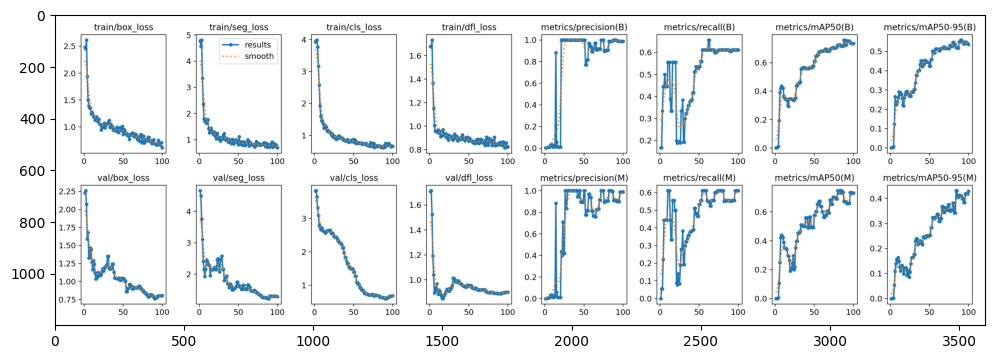

In [32]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open('./runs/segment/train4/results.png')
img_np = np.array(img)
plt.figure(figsize=(12,5))
plt.imshow(img_np)
plt.show()

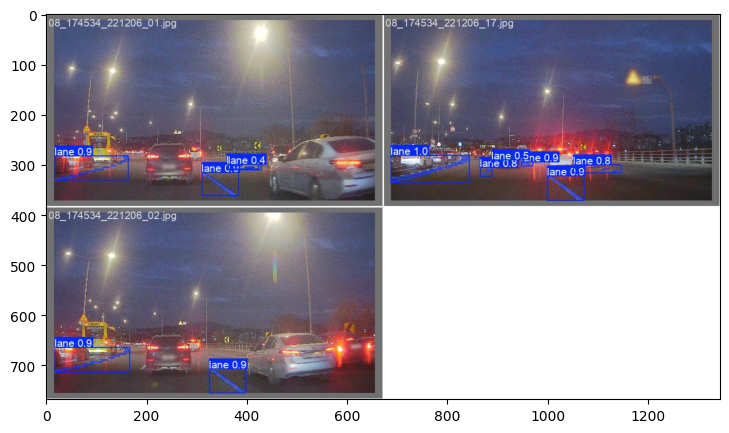

In [33]:
img = Image.open('./runs/segment/train4/val_batch0_pred.jpg')
img_np = np.array(img)
plt.figure(figsize=(12,5))
plt.imshow(img_np)
plt.show()

In [ ]:
model = YOLO('./runs/segment/train4/weights/best.pt')

model.predict(source='/content/drive/MyDrive/YOLODataset/images/test/08_174534_221206_14.jpg', save=True)

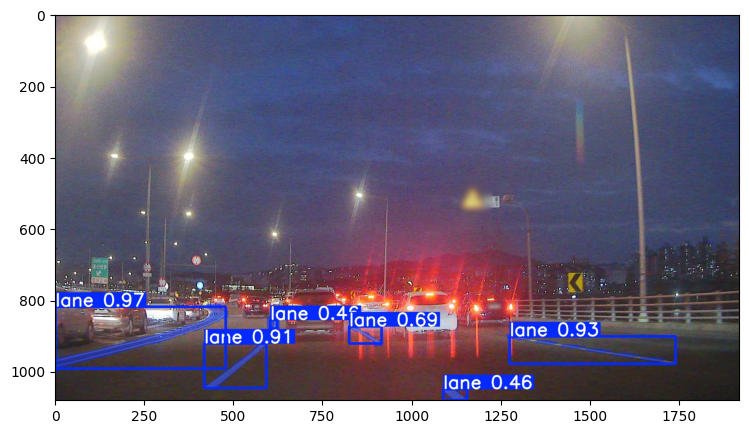

In [37]:
img = Image.open('/content/runs/segment/predict2/08_174534_221206_14.jpg')
img_np = np.array(img)
plt.figure(figsize=(12,5))
plt.imshow(img_np)
plt.show()